# QPMwP CODING EXAMPLES - BLACK LITTERMAN MODEL

This script demonstrates the application of the Black-Litterman model using the single stock datasets.


## Imports

In [10]:
# Standard library imports
import os
import sys

# Third party imports
import numpy as np
import pandas as pd

# Add the project root directory to Python path
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
src_path = os.path.join(project_root, 'qpmwp-course\\src')
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules imports
from helper_functions import (
    load_pickle,
    load_data_spi,
    align_market_data_with_jkp_data,
)
from estimation.covariance import Covariance
from estimation.black_litterman import (
    bl_posterior_mu_sigma,                              # NEW!
    generate_views_from_scores,                         # NEW!
)
from optimization.optimization import (
    Objective,
    MeanVariance,
    BlackLitterman,                                     # NEW!
)
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_gaps,
    bibfn_selection_min_volume,
    bibfn_selection_jkp_data_scores,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_return_series,
    bibfn_scores,
    bibfn_cap_weights,                                  # NEW!
)
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_budget_constraint,
    bibfn_box_constraints,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest

## Constants

In [ ]:
PATH_TO_DATA = 'C:/Users/User/OneDrive/Documents/QPMwP/Data/'     # <change this to your path to data>
SAVE_PATH = 'C:/Users/User/OneDrive/Documents/QPMwP/2026/Code/'   # <change this to your path where you want to store the backtest>


# JKP_FIELDS_MOMENTUM = [
#     'prc_highprc_252d',
#     'resff3_6_1',
#     'resff3_12_1',
#     'ret_3_1',
#     'ret_6_1',
#     'ret_9_1',
#     'ret_12_1',
#     'seas_1_1na',
# ]

# # Profitability, Growth, Value, Momentum
# JKP_FIELDS_PGVM = [
#     'ni_be',        # Return on Equity (Profitability)
#     'ocf_at_chg1',  # Change in operating cash flow to assets (Growth)
#     'at_me',        # Book-to-Market ratio (Value)
#     'ret_12_1',     # 12-month momentum (Momentum)
# ]

# Quality minus junk
JKP_FIELDS_QMJ = [
    'qmj_prof',
    'qmj_growth',
    'qmj_safety',
    'qmj',  
]
    

## Load data
- market data (from parquet file)
- jkp data (from parquet file)
- swiss performance index, SPI (from csv file)

In [12]:
# Load market and jkp data from parquet files
market_data = pd.read_parquet(path = f'{PATH_TO_DATA}market_data.parquet')
jkp_data = pd.read_parquet(path = f'{PATH_TO_DATA}jkp_data.parquet')
spi = load_data_spi(path=PATH_TO_DATA)

# Align market data with jkp data
market_data_ffill, jkp_data = align_market_data_with_jkp_data(
    market_data=market_data,
    jkp_data=jkp_data,
)

# Instantiate the BacktestData class
# and set the market, jkp, and benchmark data as attributes
data = BacktestData()
data.market_data = market_data_ffill  # notice that we use the forward filled market data here
data.jkp_data = jkp_data
data.bm_series = spi

## Define the rebalancing dates

In [13]:
n_month = 3 # We want to rebalance every n_month months
jkp_data_dates = (
    jkp_data
    .index.get_level_values('date')
    .unique().sort_values()
)
rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data.index.get_level_values('date').min()
    ][::n_month]
    .strftime('%Y-%m-%d').tolist()
)
rebdates = [
    date for date in rebdates if date > '2002-01-01'
    and date < rebdates[-1]
]
rebdates

['2002-01-31',
 '2002-04-30',
 '2002-07-31',
 '2002-10-31',
 '2003-01-31',
 '2003-04-30',
 '2003-07-31',
 '2003-10-31',
 '2004-01-31',
 '2004-04-30',
 '2004-07-31',
 '2004-10-31',
 '2005-01-31',
 '2005-04-30',
 '2005-07-31',
 '2005-10-31',
 '2006-01-31',
 '2006-04-30',
 '2006-07-31',
 '2006-10-31',
 '2007-01-31',
 '2007-04-30',
 '2007-07-31',
 '2007-10-31',
 '2008-01-31',
 '2008-04-30',
 '2008-07-31',
 '2008-10-31',
 '2009-01-31',
 '2009-04-30',
 '2009-07-31',
 '2009-10-31',
 '2010-01-31',
 '2010-04-30',
 '2010-07-31',
 '2010-10-31',
 '2011-01-31',
 '2011-04-30',
 '2011-07-31',
 '2011-10-31',
 '2012-01-31',
 '2012-04-30',
 '2012-07-31',
 '2012-10-31',
 '2013-01-31',
 '2013-04-30',
 '2013-07-31',
 '2013-10-31',
 '2014-01-31',
 '2014-04-30',
 '2014-07-31',
 '2014-10-31',
 '2015-01-31',
 '2015-04-30',
 '2015-07-31',
 '2015-10-31',
 '2016-01-31',
 '2016-04-30',
 '2016-07-31',
 '2016-10-31',
 '2017-01-31',
 '2017-04-30',
 '2017-07-31',
 '2017-10-31',
 '2018-01-31',
 '2018-04-30',
 '2018-07-

## Define the selection and optimization item builders

In [14]:

# Define the selection item builders.
selection_item_builders = {
    'gaps': SelectionItemBuilder(
        bibfn=bibfn_selection_gaps,
        width=365,
        n_days=10,
    ),
    'min_volume': SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=365,
        min_volume=500_000,
        agg_fn=np.median,
    ),
    'jkp_data_scores': SelectionItemBuilder(
        bibfn=bibfn_selection_jkp_data_scores,
        # fields=JKP_FIELDS_MOMENTUM,
        # fields=JKP_FIELDS_PGVM,
        fields=JKP_FIELDS_QMJ,
    ),
}

# Define the optimization item builders.
optimization_item_builders = {
    'return_series': OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=365 * 3,
        fill_value=0,
    ),
    'scores': OptimizationItemBuilder(
        bibfn=bibfn_scores,
        # fields=JKP_FIELDS_MOMENTUM,
        # fields=JKP_FIELDS_PGVM,
        fields=JKP_FIELDS_QMJ,
    ),
    'cap_weights': OptimizationItemBuilder(
        bibfn=bibfn_cap_weights,
    ),
    'budget_constraint': OptimizationItemBuilder(
        bibfn=bibfn_budget_constraint,
        budget=1
    ),
    'box_constraints': OptimizationItemBuilder(
        bibfn=bibfn_box_constraints,
        upper=0.1
    ),
}

## Define the optimization object

In [15]:
# Initialize the Black-Litterman optimization object
optimization = BlackLitterman(
    solver_name='cvxopt',
    covariance=Covariance(method='pearson'),
    tau_psi=0.01,
    tau_omega=0.00001,
    # view_gen_algo='complete_sort',
    # view_gen_algo='longshort_sort',
    view_gen_algo='quintile_sort',
    signal_names=JKP_FIELDS_QMJ,
)

## Initialize the backtest service

In [16]:
bs = BacktestService(
    data=data,
    selection_item_builders=selection_item_builders,
    optimization_item_builders=optimization_item_builders,
    optimization=optimization,
    rebdates=rebdates,
)

## Run the backtest

In [17]:
# bt_bl = Backtest()
# bt_bl.run(bs=bs)

In [18]:
# # Save the backtest as a .pickle file
# bt_bl.save(
#     path=SAVE_PATH,
#     # filename=f'demo_backtest_8_bl_qmj_cs.pickle' # if view_gen_algo='complete_sort'
#     # filename=f'demo_backtest_8_bl_qmj_ls.pickle' # if view_gen_algo='longshort_sort'
#     filename=f'demo_backtest_8_bl_qmj_qs.pickle' # if view_gen_algo='quintile_sort'
# )

## Simulate

In [19]:
# Laod backtests from pickle
bt_bl_qmj_cs = load_pickle(
    filename='demo_backtest_8_bl_qmj_cs.pickle',
    path=SAVE_PATH,
)
bt_bl_qmj_ls = load_pickle(
    filename='demo_backtest_8_bl_qmj_ls.pickle',
    path=SAVE_PATH,
)
bt_bl_qmj_qs = load_pickle(
    filename='demo_backtest_8_bl_qmj_qs.pickle',
    path=SAVE_PATH,
)

<Axes: title={'center': 'Cumulative Performance'}>

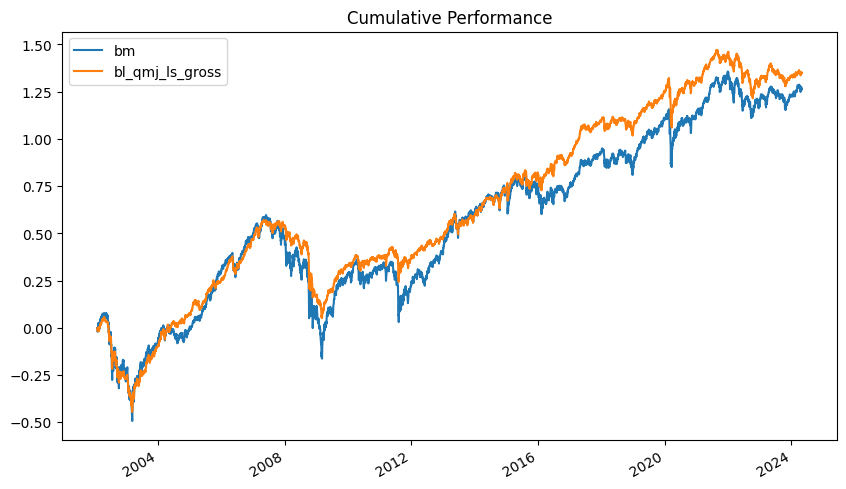

In [20]:
fixed_costs = 0.01
variable_costs = 0.002
return_series = bs.data.get_return_series(weekdays_only=False)

strategy_dict = {
    # 'bl_qmj_cs': bt_bl_qmj_cs.strategy,
    'bl_qmj_ls': bt_bl_qmj_ls.strategy,
    # 'bl_qmj_qs': bt_bl_qmj_qs.strategy,
}

sim_dict_gross = {
    f'{key}_gross': value.simulate(
        return_series=return_series,
        fc=0,
        vc=0,
    )
    for key, value in strategy_dict.items()
}
# sim_dict_net = {
#     f'{key}_net': value.simulate(
#         return_series=return_series,
#         fc=fixed_costs,
#         vc=variable_costs,
#     )
#     for key, value in strategy_dict.items()
# }

sim = pd.concat({
    'bm': bs.data.bm_series,
    **sim_dict_gross,
    # **sim_dict_net,
}, axis = 1).dropna()

np.log((1 + sim)).cumsum().plot(title='Cumulative Performance', figsize = (10, 6))

## Descriptive statistics

In [21]:
import empyrical as ep

# Compute individual performance metrics for each simulated strategy using empyrical
annual_return = {}
cumulative_returns = {}
annual_volatility = {}
sharpe_ratio = {}
max_drawdown = {}
tracking_error = {}
for column in sim.columns:
    print(f'Performance metrics for {column}')
    annual_return[column] = ep.annual_return(sim[column])
    cumulative_returns[column] = ep.cum_returns(sim[column]).tail(1).values[0]
    annual_volatility[column] = ep.annual_volatility(sim[column])
    sharpe_ratio[column] = ep.sharpe_ratio(sim[column])
    max_drawdown[column] = ep.max_drawdown(sim[column])
    tracking_error[column] = ep.annual_volatility(sim[column] - sim['bm'])


annual_returns = pd.DataFrame(annual_return, index=['Annual Return'])
cumret = pd.DataFrame(cumulative_returns, index=['Cumulative Return'])
annual_volatility = pd.DataFrame(annual_volatility, index=['Annual Volatility'])
sharpe  = pd.DataFrame(sharpe_ratio, index=['Sharpe Ratio'])
mdd = pd.DataFrame(max_drawdown, index=['Max Drawdown'])
pd.concat([annual_returns, cumret, annual_volatility, sharpe, mdd])

Performance metrics for bm
Performance metrics for bl_qmj_ls_gross


,bm,bl_qmj_ls_gross
Annual Return,0.055644,0.059650
Cumulative Return,2.532512,2.858586
Annual Volatility,0.164658,0.107385
Sharpe Ratio,0.411353,0.593461
Max Drawdown,-0.532487,-0.404436


## Go through the optimization step-by-step for a particular date

In [27]:
# Increase the minimum volume filter so that we have less stocks in the selection
bs.selection_item_builders['min_volume'].arguments['min_volume'] = 100_000_000 # instead of 500_000

# Define a date for the optimization
date = rebdates[-10]
print(f'Optimization date: {date}\n')

# Prepare optimization for the given date
bs.prepare_rebalancing(date)
# bs.optimization.set_objective(bs.optimization_data)

# Inspect the selction for the given date
bs.selection.df()

# Inspect the optimization data for the given date
bs.optimization_data.keys()
bs.optimization_data['scores']

# Extract scores
scores = bs.optimization_data['scores']
print(f'Scores: {scores}\n')

# Extract the cap-weights
cap_weights = bs.optimization_data['cap_weights']
print(f'Cap Weights: {cap_weights}\n')

# Compute the covariance matrix
covariance = Covariance(method='pearson')
return_series = bs.optimization_data['return_series']
covariance.estimate(return_series, inplace=True)

# Calculate implied expected return from
# the cap-weights, the covariance matrix and the risk aversion
risk_aversion = 1
mu_implied = risk_aversion * covariance.matrix @ cap_weights
print(f'Implied Expected Returns: {mu_implied}\n')

Optimization date: 2021-07-31

Scores:      qmj_prof  qmj_growth  qmj_safety       qmj
id                                             
122  0.492707   -0.868115   -0.860267 -0.717864
129 -0.644309    0.834726   -0.384048 -0.333890
149 -0.780751   -0.784642    0.168981 -0.801337
185 -0.189503    0.801337    1.106057  0.984976
201  0.144022    0.133556    0.261152  0.133556
24   0.962674    0.818031    0.537667  1.252089
36  -1.159757    1.001671   -0.737372 -0.667781
40  -1.417480   -0.901504   -0.138257 -1.118532
46   0.432066    1.602673   -0.629838  0.851420
48   0.932353    1.252089    0.414772  1.318867

Cap Weights: id
122    0.067154
129    0.061345
149    0.075437
185    0.061039
201    0.058241
24     0.358397
36     0.026770
40     0.028880
46     0.036272
48     0.226464
Name: mktcap, dtype: float64

Implied Expected Returns: id
122    0.000110
129    0.000124
149    0.000116
185    0.000108
201    0.000104
24     0.000077
36     0.000139
40     0.000109
46     0.000114
48   

###  Construct the views

In [29]:
P_tmp = {}
q_tmp = {}
for col in scores.columns:
    P_tmp[col], q_tmp[col] = generate_views_from_scores(
        scores=scores[col],
        mu_ref=mu_implied,
        method='quintile_sort',
        # method='longshort_sort',
        # method='complete_sort',
        scalefactor=1,
    )
    
P = pd.concat(P_tmp, axis=0)
q = pd.concat(q_tmp, axis=0)

print(f'P: {P.head(5)}\n')
print(f'q: {q}\n')
print(f'Scores: {scores.head(5)}\n')

P: id           122  129  149  185  201   24   36   40   46   48
qmj_prof Q1  0.0  0.0  0.0  0.0  0.0  0.0  0.5  0.5  0.0  0.0
         Q2  0.0  0.5  0.5  0.0  0.0  0.0  0.0  0.0  0.0  0.0
         Q3  0.0  0.0  0.0  0.5  0.5  0.0  0.0  0.0  0.0  0.0
         Q4  0.5  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.5  0.0
         Q5  0.0  0.0  0.0  0.0  0.0  0.5  0.0  0.0  0.0  0.5

q: qmj_prof    Q1    0.000086
            Q2    0.000106
            Q3    0.000109
            Q4    0.000115
            Q5    0.000131
qmj_growth  Q1    0.000086
            Q2    0.000106
            Q3    0.000109
            Q4    0.000115
            Q5    0.000131
qmj_safety  Q1    0.000086
            Q2    0.000106
            Q3    0.000109
            Q4    0.000115
            Q5    0.000131
qmj         Q1    0.000086
            Q2    0.000106
            Q3    0.000109
            Q4    0.000115
            Q5    0.000131
dtype: float64

Scores:      qmj_prof  qmj_growth  qmj_safety       qmj
id       

### Compute the posterior

Omega:                qmj_prof                                         qmj_growth  \
                     Q1        Q2        Q3        Q4        Q5         Q1   
qmj_prof   Q1  0.000001  0.000000  0.000000  0.000000  0.000000   0.000000   
           Q2  0.000000  0.000001  0.000000  0.000000  0.000000   0.000000   
           Q3  0.000000  0.000000  0.000001  0.000000  0.000000   0.000000   
           Q4  0.000000  0.000000  0.000000  0.000001  0.000000   0.000000   
           Q5  0.000000  0.000000  0.000000  0.000000  0.000001   0.000000   
qmj_growth Q1  0.000000  0.000000  0.000000  0.000000  0.000000   0.000001   
           Q2  0.000000  0.000000  0.000000  0.000000  0.000000   0.000000   
           Q3  0.000000  0.000000  0.000000  0.000000  0.000000   0.000000   
           Q4  0.000000  0.000000  0.000000  0.000000  0.000000   0.000000   
           Q5  0.000000  0.000000  0.000000  0.000000  0.000000   0.000000   
qmj_safety Q1  0.000000  0.000000  0.000000  0.000000  0.

<Axes: xlabel='id'>

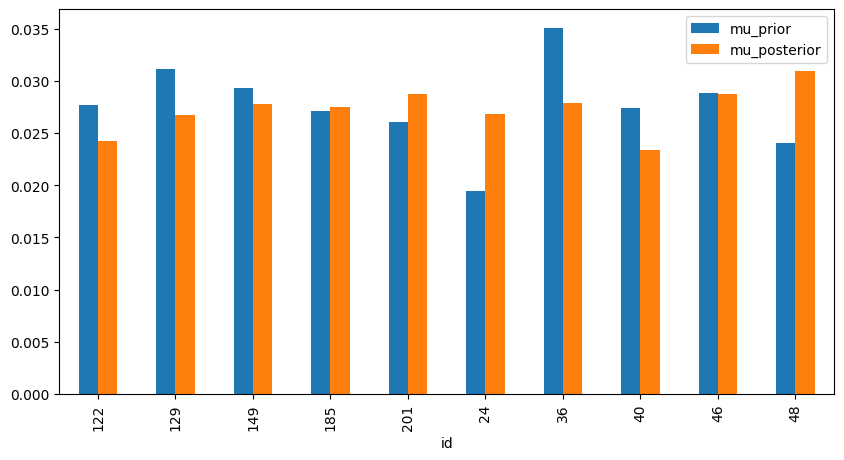

In [30]:
# Tuning parameters
tau_psi = 0.01
# tau_omega = 0.0001
tau_omega = 0.000001

# Uncertainty of the views
Omega = pd.DataFrame(
    np.diag([tau_omega] * len(q)),
    index=q.index,
    columns=q.index
)
print(f'Omega: {Omega}\n')

#  Uncertainty of the prior
Psi = covariance.matrix * tau_psi
print(f'Psi: {Psi}\n')

# Compute the posterior expected return vector
mu_posterior, sigma_posterior = bl_posterior_mu_sigma(
    mu_prior=mu_implied,
    covmat=covariance.matrix,
    P=P,
    q=q,
    Psi=Psi,
    Omega=Omega,
)

# Compare the prior and the posterior expected return vectors
Mu = pd.concat({
    "mu_prior": mu_implied,
    "mu_posterior": mu_posterior,
}, axis=1) * 252
# Mu.sort_values("mu_prior", ascending=False, inplace=True)
print(f'Mu: {Mu}\n')
Mu.plot(kind="bar", figsize=(10, 5))

### Optimize and inspect the weights

<Axes: >

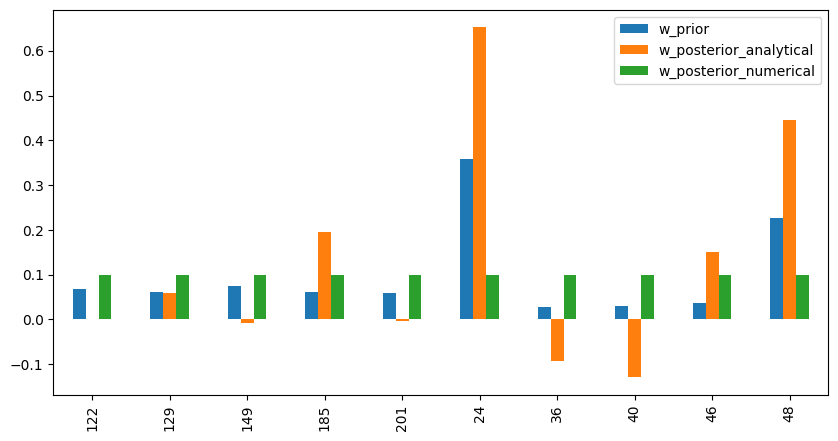

In [31]:
# Compute the analytical mean-variance optimization with the posterior returns
w_posterior_analytical = pd.Series(np.linalg.inv(risk_aversion * covariance.matrix) @ mu_posterior, index=mu_posterior.index)

# Re-run the mean-variance optimization with the posterior returns
mv = MeanVariance(
    constraints=bs.optimization.constraints,
    solver_name="cvxopt",
)
mv.objective = Objective(
    q=mu_posterior * (-1),
    P=covariance.matrix * 2,
)
mv.solve()
w_posterior_numerical = pd.Series(mv.results["weights"])

W = pd.DataFrame([cap_weights, w_posterior_analytical, w_posterior_numerical],
                 index=["w_prior", "w_posterior_analytical", "w_posterior_numerical"]).T
W.plot(kind="bar", figsize=(10, 5))